In [381]:
'''
Heart Disease Prediction System:

This system uses patient clinical data like age, BP,
cholesterol, etc. Data is cleaned, missing values 
removed, and scaling is applied so all features are 
in same range. Feature selection means selecting most
important attributes (like cholesterol, BP) so model becomes 
fast and accurate. Logistic Regression and KNN are trained to 
classify risk or no risk. Performance is checked using accuracy
, precision, recall, and F1-score.
'''

'\nHeart Disease Prediction System:\n\nThis system uses patient clinical data like age, BP,\ncholesterol, etc. Data is cleaned, missing values \nremoved, and scaling is applied so all features are \nin same range. Feature selection means selecting most\nimportant attributes (like cholesterol, BP) so model becomes \nfast and accurate. Logistic Regression and KNN are trained to \nclassify risk or no risk. Performance is checked using accuracy\n, precision, recall, and F1-score.\n'

In [382]:
%pip install seaborn 

In [383]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import roc_curve, auc
df = pd.read_csv("heart.csv")

In [384]:
# PHASE-1 (DATASET COLLLECTION) 


In [385]:
print("--- Dataset Shape (Rows, Columns) ---\n")
print(df.shape)

--- Dataset Shape (Rows, Columns) ---

(918, 13)


In [386]:
print("--- Dataset Information ---\n")
print(df.info())

--- Dataset Information ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          917 non-null    object 
 1   Age           918 non-null    int64  
 2   Sex           917 non-null    object 
 3   cp            918 non-null    object 
 4   RestingBP     917 non-null    float64
 5   chol          918 non-null    int64  
 6   fbs           918 non-null    int64  
 7   RestingECG    915 non-null    object 
 8   MaxHR         917 non-null    float64
 9   exang         918 non-null    object 
 10  Oldpeak       916 non-null    float64
 11  ST_Slope      917 non-null    object 
 12  HeartDisease  918 non-null    int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 71.8+ KB
None


In [387]:
print("--- Dataset Preview ---\n")
print(df.head())

--- Dataset Preview ---

              name  Age   Sex   cp  RestingBP  chol  fbs RestingECG  MaxHR  \
0      Mary Miller   40     m  ATA      140.0   289    0     Normal  172.0   
1   Michael Garcia   49     f  NAP      160.0   180    0     Normal  156.0   
2  Thomas Gonzalez   37  Male  ATA      130.0   283    0         ST   98.0   
3     Karen Garcia   48     f  ASY      138.0   214    0     Normal  108.0   
4     Thomas Smith   54     m  NAP      150.0   195    0     Normal  122.0   

  exang  Oldpeak ST_Slope  HeartDisease  
0     N      0.0       Up             0  
1     N      1.0     Flat             1  
2     N      0.0       Up             0  
3     Y      1.5     Flat             1  
4     N      0.0       Up             0  


In [388]:
print("--- Statistical Summary ---\n")
print(df.describe())

--- Statistical Summary ---

              Age   RestingBP         chol         fbs       MaxHR  \
count  918.000000  917.000000   918.000000  918.000000  917.000000   
mean    53.615468  132.682661   200.498911    0.233115  136.815703   
std      9.955696   21.228551   116.519404    0.423046   27.507955   
min     28.000000    0.000000     0.000000    0.000000   10.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max    150.000000  450.000000  1200.000000    1.000000  400.000000   

          Oldpeak  HeartDisease  
count  916.000000    918.000000  
mean     0.916812      0.553377  
std      2.007298      0.497414  
min    -10.000000      0.000000  
25%      0.000000      0.000000  
50%      0.550000      1.000000  
75%      1.500000      1.000000  
max     50.000000      1.000000  


In [389]:
# PHASE-2 (DATA CLEANING) 


In [390]:
df_clean=df.copy()

In [391]:
print(df_clean.head())

              name  Age   Sex   cp  RestingBP  chol  fbs RestingECG  MaxHR  \
0      Mary Miller   40     m  ATA      140.0   289    0     Normal  172.0   
1   Michael Garcia   49     f  NAP      160.0   180    0     Normal  156.0   
2  Thomas Gonzalez   37  Male  ATA      130.0   283    0         ST   98.0   
3     Karen Garcia   48     f  ASY      138.0   214    0     Normal  108.0   
4     Thomas Smith   54     m  NAP      150.0   195    0     Normal  122.0   

  exang  Oldpeak ST_Slope  HeartDisease  
0     N      0.0       Up             0  
1     N      1.0     Flat             1  
2     N      0.0       Up             0  
3     Y      1.5     Flat             1  
4     N      0.0       Up             0  


In [392]:
df_clean.drop('name', axis=1, inplace=True, errors='ignore')
print("--- null values count ---\n")
print(df_clean.isnull().sum())

--- null values count ---

Age             0
Sex             1
cp              0
RestingBP       1
chol            0
fbs             0
RestingECG      3
MaxHR           1
exang           0
Oldpeak         2
ST_Slope        1
HeartDisease    0
dtype: int64


In [393]:
df_clean['Sex'] = df_clean['Sex'].replace({
    'Male':1,'Female':0,'M':1,'F':0,
    'female':0,'male':1,'f':0,'m':1
})
df_clean['Sex'] = df_clean['Sex'].fillna(df_clean['Sex'].mode()[0])
print(df_clean['Sex'].head())

<ipython-input-393-e67a299e660b>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Sex'] = df_clean['Sex'].replace({


0    1.0
1    0.0
2    1.0
3    0.0
4    1.0
Name: Sex, dtype: float64


In [394]:
df_clean['exang'] = df_clean['exang'].map({'N': 0, 'Y': 1})
df_clean['exang'] = df_clean['exang'].fillna(df_clean['exang'].mode()[0])
print(df_clean['exang'].head())

0    0
1    0
2    0
3    1
4    0
Name: exang, dtype: int64


In [395]:
df_clean['chol'] = df_clean['chol'].replace(0, np.nan)
df_clean['chol'] = df_clean['chol'].fillna(df_clean['chol'].median())
print(df_clean['chol'].head())

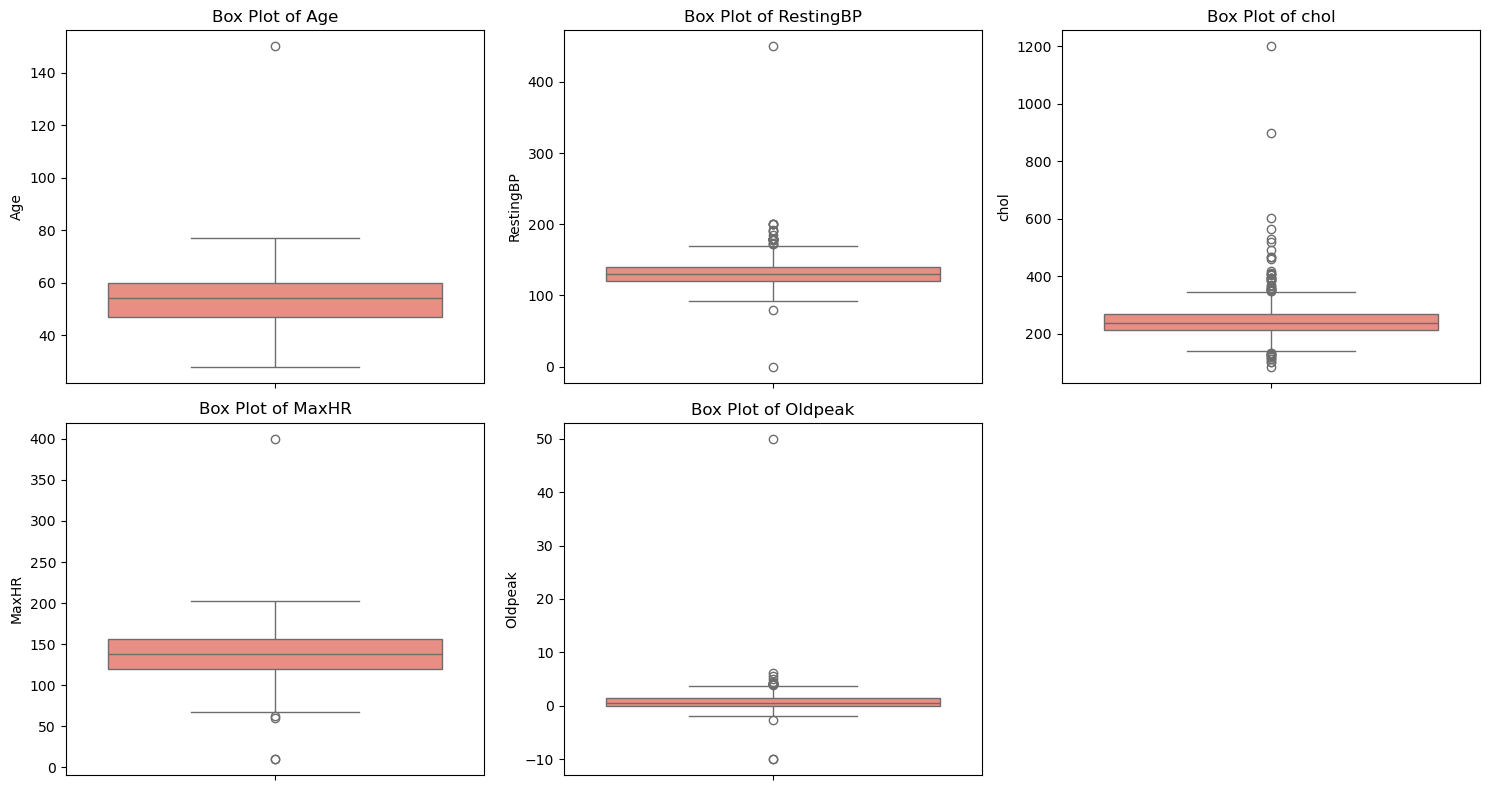

In [396]:
num_cols = ['Age', 'RestingBP', 'chol', 'MaxHR', 'Oldpeak']
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_clean[col], color='salmon')
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

In [397]:
constraints = {
    'Age': [0, 120],          
    'RestingBP': [50, 300],    
    'chol': [50, 400],         
    'MaxHR': [50, 220],       
    'Oldpeak': [0,6]       
}
print(f"Original shape: {df_clean.shape}")

for col, bounds in constraints.items():
    if col in df_clean.columns:
        initial_count = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= bounds[0]) & (df_clean[col] <= bounds[1])]
        dropped = initial_count - len(df_clean)
        if dropped > 0:
            print(f"Removed {dropped} rows from '{col}' exceeding range {bounds}")

print(f"\nFinal cleaned shape: {df_clean.shape}")

Original shape: (918, 12)
Removed 1 rows from 'Age' exceeding range [0, 120]
Removed 3 rows from 'RestingBP' exceeding range [50, 300]
Removed 15 rows from 'chol' exceeding range [50, 400]
Removed 4 rows from 'MaxHR' exceeding range [50, 220]
Removed 19 rows from 'Oldpeak' exceeding range [0, 6]

Final cleaned shape: (876, 12)


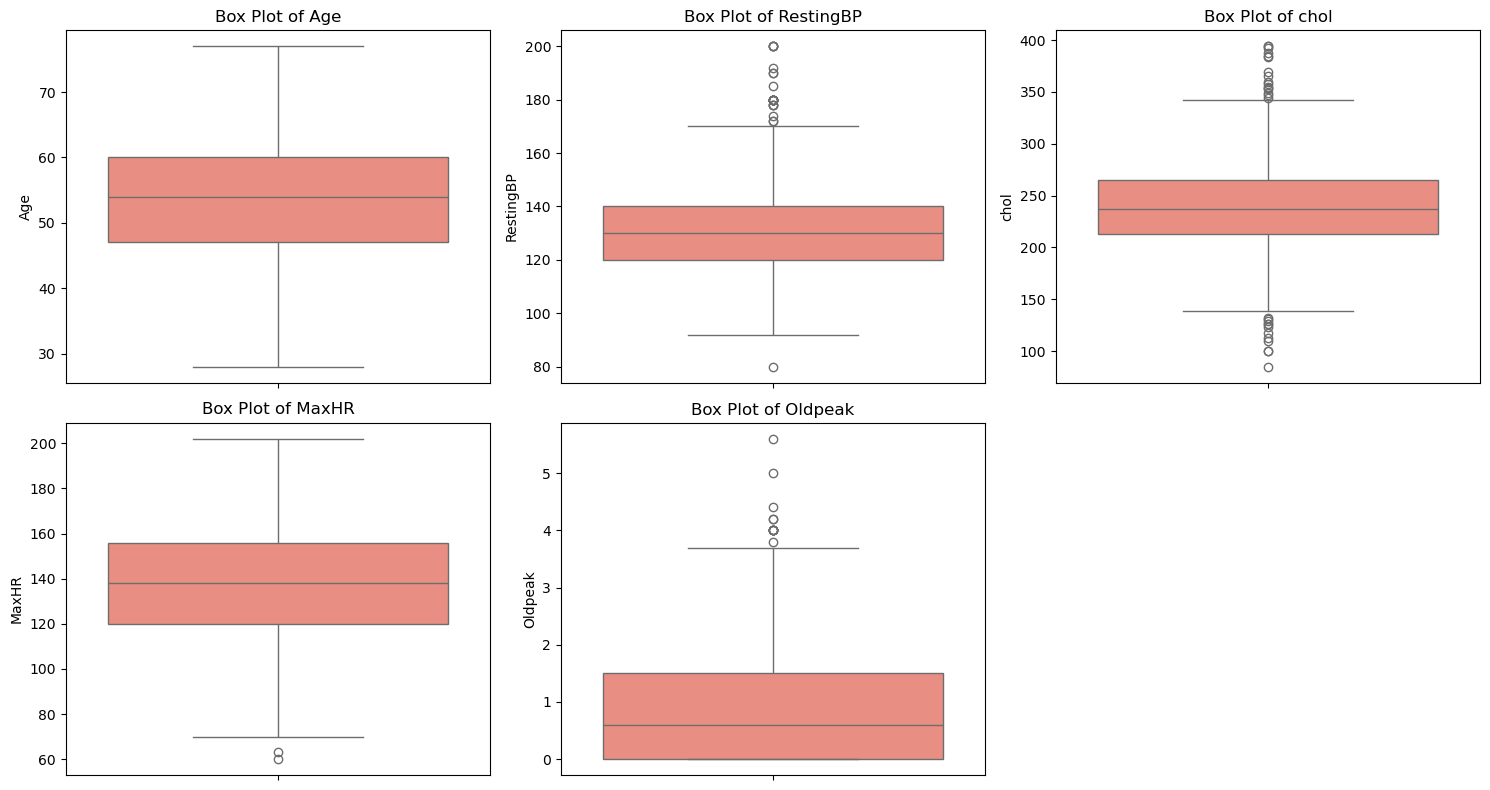

In [398]:
num_cols = ['Age', 'RestingBP', 'chol', 'MaxHR', 'Oldpeak']
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_clean[col], color='salmon')
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

In [399]:
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, np.nan)
cols_to_median = ['Oldpeak', 'RestingBP']
df_clean[cols_to_median] = df_clean[cols_to_median].fillna(df_clean[cols_to_median].median())
cols_to_mode = ['Sex', 'RestingECG', 'ST_Slope', 'HeartDisease']
for col in cols_to_mode:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
df_clean['MaxHR'] = df_clean['MaxHR'].fillna(df_clean['MaxHR'].mean())
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)

print(df_clean.isnull().sum())

Age             0
Sex             0
cp              0
RestingBP       0
chol            0
fbs             0
RestingECG      0
MaxHR           0
exang           0
Oldpeak         0
ST_Slope        0
HeartDisease    0
dtype: int64


In [400]:
categorical_cols = ['cp', 'RestingECG', 'ST_Slope']
for col in categorical_cols:
    if col in df_clean.columns:
        mode = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode)
        encoded = pd.get_dummies(df_clean[col], prefix=col, drop_first=True).astype(int)
        df_clean = pd.concat([df_clean, encoded], axis=1)
        df_clean.drop(col, axis=1, inplace=True)
print(df_clean.columns.tolist())
print("\n")
print(df_clean.head())

['Age', 'Sex', 'RestingBP', 'chol', 'fbs', 'MaxHR', 'exang', 'Oldpeak', 'HeartDisease', 'cp_ATA', 'cp_NAP', 'cp_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


   Age  Sex  RestingBP   chol  fbs  MaxHR  exang  Oldpeak  HeartDisease  \
0   40  1.0      140.0  289.0    0  172.0      0      0.0             0   
1   49  0.0      160.0  180.0    0  156.0      0      1.0             1   
2   37  1.0      130.0  283.0    0   98.0      0      0.0             0   
3   48  0.0      138.0  214.0    0  108.0      1      1.5             1   
4   54  1.0      150.0  195.0    0  122.0      0      0.0             0   

   cp_ATA  cp_NAP  cp_TA  RestingECG_Normal  RestingECG_ST  ST_Slope_Flat  \
0       1       0      0                  1              0              0   
1       0       1      0                  1              0              1   
2       1       0      0                  0              1              0   
3       0       0      0                  1         


--- Features Correlated with Heart Disease ---

HeartDisease         1.000000
ST_Slope_Flat        0.554970
exang                0.501349
Oldpeak              0.433338
Sex                  0.315578
Age                  0.289115
fbs                  0.268817
RestingBP            0.117943
RestingECG_ST        0.102419
chol                 0.071163
cp_TA               -0.059331
RestingECG_Normal   -0.094900
cp_NAP              -0.205118
MaxHR               -0.402638
cp_ATA              -0.403515
ST_Slope_Up         -0.621051
Name: HeartDisease, dtype: float64


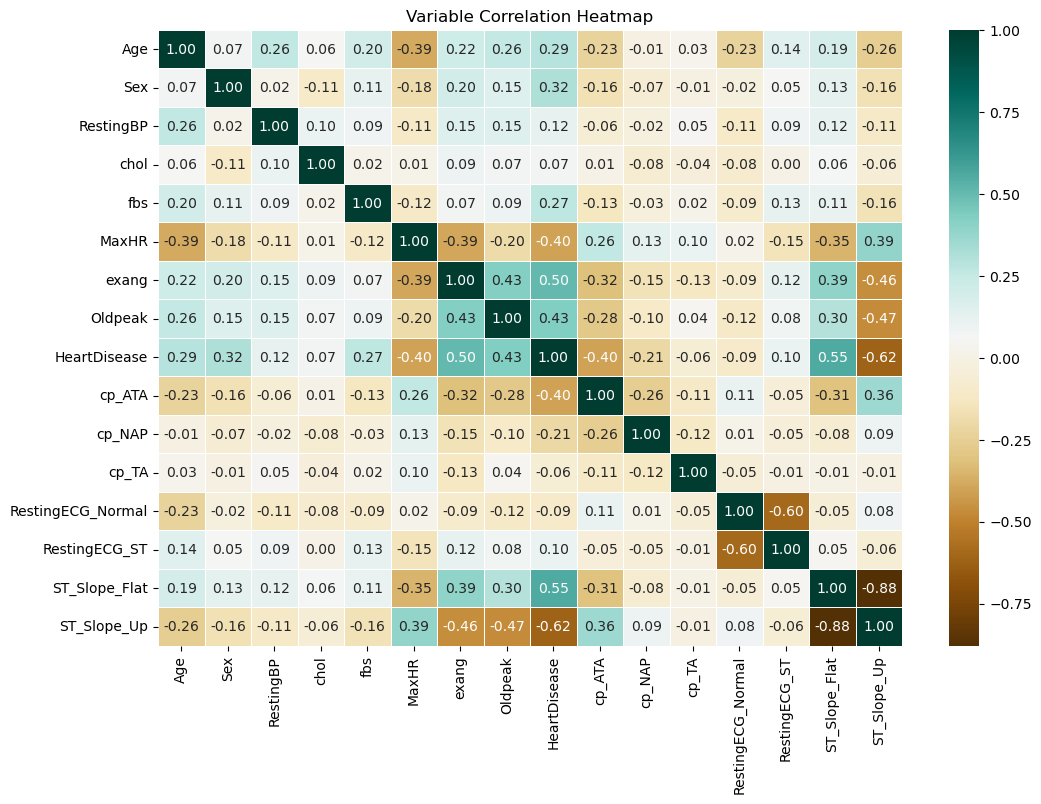


--- Selected Important Features ---

HeartDisease     1.000000
ST_Slope_Flat    0.554970
exang            0.501349
Oldpeak          0.433338
Sex              0.315578
Age              0.289115
fbs              0.268817
RestingBP        0.117943
RestingECG_ST    0.102419
cp_NAP          -0.205118
MaxHR           -0.402638
cp_ATA          -0.403515
ST_Slope_Up     -0.621051
Name: HeartDisease, dtype: float64


In [401]:
correlation_matrix = df_clean.corr(numeric_only=True)
target_corr = correlation_matrix['HeartDisease'].sort_values(ascending=False)
print("\n--- Features Correlated with Heart Disease ---\n")
print(target_corr)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='BrBG', fmt=".2f", linewidths=0.5)
plt.title("Variable Correlation Heatmap")
plt.show()

important_features = target_corr[abs(target_corr) >= 0.1].sort_values(ascending=False)
print("\n--- Selected Important Features ---\n")
print(important_features)

In [402]:
features = important_features.index.drop('HeartDisease')
X = df_clean[features]
y = df_clean['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
num_cols = ['Oldpeak', 'MaxHR', 'RestingBP', 'Age', 'chol']

scale_these = X.columns.intersection(num_cols)

X_train[scale_these] = scaler.fit_transform(X_train[scale_these])
X_test[scale_these] = scaler.transform(X_test[scale_these])

print("Data Scaled Successfully\n")
print(X_train[scale_these].head())

Data Scaled Successfully

      Oldpeak       Age  RestingBP     MaxHR
423  0.553244  0.655411   2.666237  0.127417
574  0.553244  1.619026   0.503192 -0.982035
551 -0.869151  0.869548  -0.749096 -2.012240
806  1.596333  1.726095   0.673959 -0.466932
245  1.027375  0.013001  -0.749096  0.008547


In [403]:
# PHASE-3 (train model)

In [404]:
#logistic Regression

lr_model = LogisticRegression(C=0.1, random_state=42)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [405]:
sfs = SequentialFeatureSelector(lr_model, 
                                n_features_to_select=9, 
                                direction='forward')

sfs.fit(X_train, y_train)
selected_features = X_train.columns[sfs.get_support()]
print("--- Features Selected by Forward Selection ---")
print(list(selected_features))
X_train_sfs = X_train[selected_features]
X_test_sfs = X_test[selected_features]

--- Features Selected by Forward Selection ---
['exang', 'Oldpeak', 'Sex', 'fbs', 'RestingBP', 'RestingECG_ST', 'cp_NAP', 'cp_ATA', 'ST_Slope_Up']


In [406]:
lr_model_sfs = LogisticRegression(C=1, random_state=42, penalty='l2', solver='liblinear', max_iter=1000)
lr_model_sfs.fit(X_train_sfs, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [407]:
y_pred_lr = lr_model_sfs.predict(X_test_sfs)
print(y_pred_lr)

[1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 0 0 1 0 0 0 0 1 1 1 1 0 1 1 0 0
 0 1 1 0 1 0 1 0 0 0 0 0 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 1 1 1
 0 1 1 1 1 0 0 1 0 1 0 1 1 1 1 1 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 1 1 0
 1 0 0 1 1 0 0 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 1 0 1 1 1]


In [408]:
print("Logistic Regression Accuracy\n")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy

Accuracy: 0.9034090909090909


In [409]:
cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix\n")
print(cm)

Confusion Matrix

[[67  5]
 [12 92]]


In [410]:
print("Classification Report\n")
print(classification_report(y_test, y_pred_lr))

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        72
           1       0.95      0.88      0.92       104

    accuracy                           0.90       176
   macro avg       0.90      0.91      0.90       176
weighted avg       0.91      0.90      0.90       176



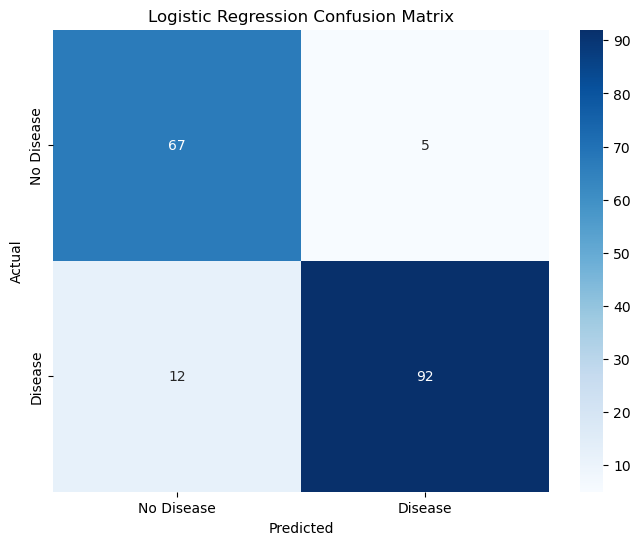

In [411]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [412]:
#KNN

print("KNN Accuracy Analysis for Different K Values\n")
accuracy_list = []

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sfs, y_train)
    y_pred = knn.predict(X_test_sfs)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)
    print(f"K={k}, Accuracy={round(acc, 4)}")

KNN Accuracy Analysis for Different K Values

K=1, Accuracy=0.7898
K=2, Accuracy=0.7557
K=3, Accuracy=0.8409
K=4, Accuracy=0.8352
K=5, Accuracy=0.8693
K=6, Accuracy=0.858
K=7, Accuracy=0.892
K=8, Accuracy=0.8807
K=9, Accuracy=0.9034
K=10, Accuracy=0.8807


In [413]:
best_k = accuracy_list.index(max(accuracy_list)) + 1
print("\nBest K:", best_k)
print("Best Accuracy:", round(max(accuracy_list), 4))


Best K: 9
Best Accuracy: 0.9034


In [414]:
knn_model = KNeighborsClassifier(n_neighbors=best_k , weights='distance', metric='minkowski', p=2)
knn_model.fit(X_train_sfs, y_train)

,n_neighbors,9
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [415]:
y_pred_knn = knn_model.predict(X_test_sfs)

In [416]:
print("KNN Accuracy\n")
print("Final KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy

Final KNN Accuracy: 0.8806818181818182


In [417]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

[[63  9]
 [12 92]]


In [418]:
print("Classification Report\n")
print(classification_report(y_test, y_pred_knn))

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        72
           1       0.91      0.88      0.90       104

    accuracy                           0.88       176
   macro avg       0.88      0.88      0.88       176
weighted avg       0.88      0.88      0.88       176



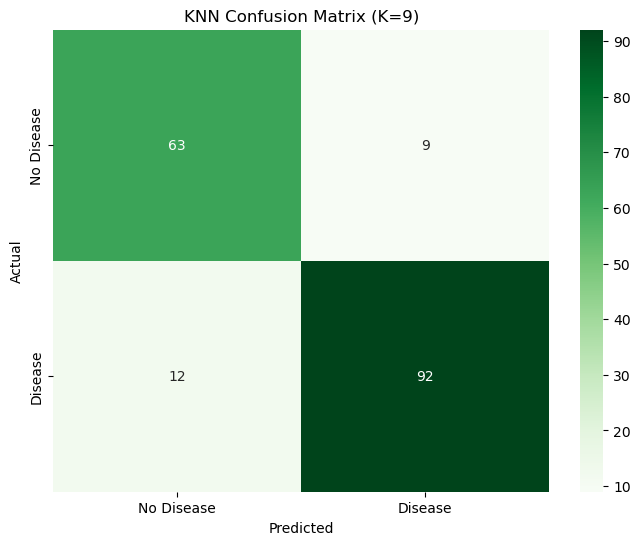

In [419]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f"KNN Confusion Matrix (K={best_k})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [420]:
# Model Comparison

In [421]:
selected_features = X_train.columns[sfs.get_support()]
print("Selected Features:", list(selected_features))
X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]
lr_model = LogisticRegression(C=1.0, random_state=42)
lr_model.fit(X_train_final, y_train)
knn_model = KNeighborsClassifier(n_neighbors=9, weights='distance')
knn_model.fit(X_train_final, y_train)
y_prob_lr = lr_model.predict_proba(X_test_final)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test_final)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

Selected Features: ['exang', 'Oldpeak', 'Sex', 'fbs', 'RestingBP', 'RestingECG_ST', 'cp_NAP', 'cp_ATA', 'ST_Slope_Up']


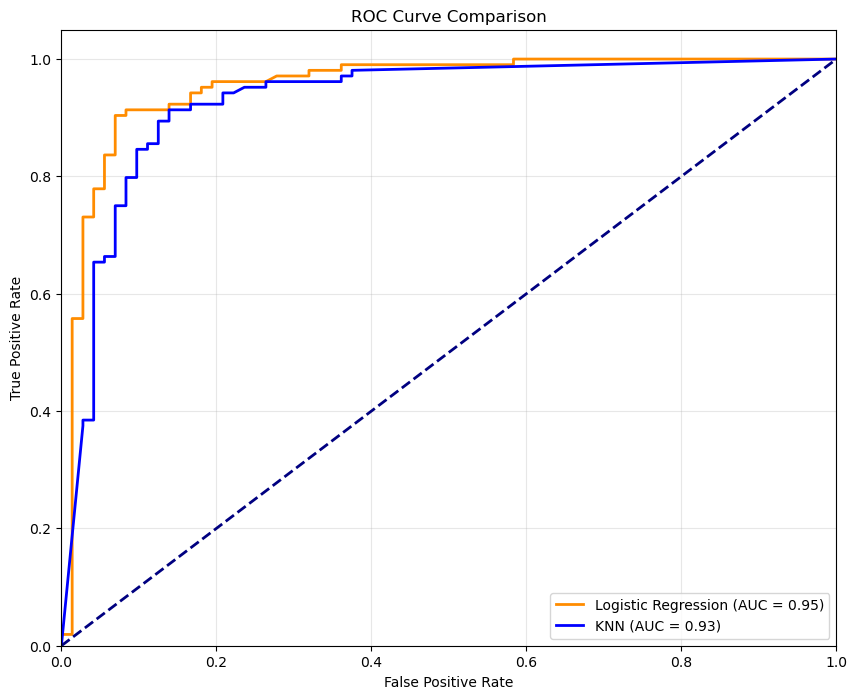

In [422]:
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, 
         label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, 
         label=f'KNN (AUC = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [423]:
#model comparision

In [424]:
print(f"Logistic Regression Accuracy: {100 * accuracy_score(y_test, y_pred_lr):.2f}%")
print(f"KNN Accuracy:                 {100 * accuracy_score(y_test, y_pred_knn):.2f}%")

Logistic Regression Accuracy: 90.34%
KNN Accuracy:                 88.07%
